# OpenAI model comparison for WP4 outlier detection

This notebook tests several OpenAI models with **the same prompt** and **the same biodiversity records**.

It produces two tables:

1. **Row-level results**: one row per record and model.
2. **Model summary**: average quality proxy, duration, token usage, estimated cost, and agreement with a baseline model.

It is meant as an evaluation notebook only. It does **not** change the FastAPI service code.

## What this notebook measures

Because there is no expert-labeled ground truth yet, the quality columns are **proxy metrics**:

- `confidence`: confidence score returned by the model.
- `suspicious`: whether the model marked the record as suspicious.
- `agreement_with_baseline`: whether the model agrees with the baseline model on `suspicious`.
- `confidence_delta_to_baseline`: difference between the model confidence and baseline confidence.

For the meeting task, the important comparison is **quality**, **speed**, and **cost**.

In [1]:
# Optional: install missing packages in a local notebook environment.
# Uncomment if needed.
# %pip install openai pandas python-dotenv tqdm matplotlib

In [ ]:
import json
import os
import sys
import time
from datetime import datetime
from pathlib import Path
from typing import Any

import pandas as pd
from dotenv import load_dotenv
from openai import OpenAI
from tqdm.auto import tqdm

C:\Users\T490\Desktop\BiodivPipeline-wp4-outlier-detect\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:

def find_outlier_module_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    candidates = [start, *start.parents]
    for candidate in candidates:
        if (candidate / "app" / "detectors" / "llm_detector.py").exists():
            return candidate
        nested = candidate / "modules" / "local" / "outlier_detect"
        if (nested / "app" / "detectors" / "llm_detector.py").exists():
            return nested
    raise FileNotFoundError("Could not find modules/local/outlier_detect project root")

PROJECT_ROOT = find_outlier_module_root()
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: C:\Users\T490\Desktop\BiodivPipeline-wp4-outlier-detect\modules\local\outlier_detect


In [5]:
load_dotenv(PROJECT_ROOT / ".env")
load_dotenv()  

api_key = os.getenv("OPENAI_API_KEY")
if not api_key:
    raise RuntimeError(
        "OPENAI_API_KEY is missing. Create modules/local/outlier_detect/.env "
        "or export OPENAI_API_KEY before running the notebook."
    )

client = OpenAI(api_key=api_key)
print("OPENAI_API_KEY loaded:", bool(api_key))

OPENAI_API_KEY loaded: True


In [6]:

from app.detectors.llm_detector import SYSTEM_PROMPT
from app.preprocessing.bgbm_normalizer import normalize_bgbm_record

print(SYSTEM_PROMPT[:250] + "...")


You are a biodiversity and herbarium data-quality analyst.

Analyze ONE specimen record.

Your task is to detect semantic or contextual inconsistencies.

Focus on:

1. Coordinates and geography
- Do latitude and longitude fit the country?
- Do coord...


## Configuration

This cell is the only place you normally need to edit.

- `MODELS` are the smaller/cheaper models you want to compare.
- `BASELINE_MODEL` is the stronger reference model.
- You can override them without changing the notebook by setting these values in `.env`:
  - `OPENAI_MODEL_LIST=o4-mini,gpt-...-mini,gpt-...-nano`
  - `OPENAI_BASELINE_MODEL=gpt-...`

If a model name is not available for your API key, the notebook will show a warning before the API calls.


In [8]:
def env_list(name: str, default: list[str]) -> list[str]:
    raw = os.getenv(name, "").strip()
    if not raw:
        return default
    return [item.strip() for item in raw.split(",") if item.strip()]

MODELS = env_list(
    "OPENAI_MODEL_LIST",
    [
        "o4-mini",
        "gpt-5.4-mini",
        "gpt-5.4-nano",
    ],
)

BASELINE_MODEL = os.getenv("OPENAI_BASELINE_MODEL", "gpt-5.4").strip()

ALL_MODELS = list(dict.fromkeys([*MODELS, BASELINE_MODEL]))

MODEL_PRICES_USD_PER_1M_TOKENS = {
    "o4-mini": {"input": 1.10, "output": 4.40},
    "gpt-5.4-mini": {"input": 0.75, "output": 4.50},
    "gpt-5.4-nano": {"input": 0.20, "output": 1.25},
    "gpt-5.4": {"input": 2.50, "output": 15.00},
}

MAX_ROWS = int(os.getenv("MODEL_COMPARISON_MAX_ROWS", "50"))
INPUT_CSV = Path(os.getenv("MODEL_COMPARISON_INPUT_CSV", PROJECT_ROOT / "tests" / "input.csv"))
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)

print("Models to test:", ALL_MODELS)
print("Baseline model:", BASELINE_MODEL)
print("Max rows:", MAX_ROWS)
print("Input CSV:", INPUT_CSV)


Models to test: ['o4-mini', 'gpt-5.4-mini', 'gpt-5.4-nano', 'gpt-5.4']
Baseline model: gpt-5.4
Max rows: 50
Input CSV: C:\Users\T490\Desktop\BiodivPipeline-wp4-outlier-detect\modules\local\outlier_detect\tests\input.csv


## Validate model availability

This checks whether the configured model names are visible to your OpenAI API key. If a name is missing, edit `MODELS` / `BASELINE_MODEL` above or set the values in `.env`.


In [ ]:
def get_available_openai_models() -> set[str]:
    try:
        return {m.id for m in client.models.list().data}
    except Exception as exc:
        print("Could not list available models. Continuing anyway.")
        print(type(exc).__name__, str(exc))
        return set()

available_models = get_available_openai_models()
if available_models:
    unavailable_models = [model for model in ALL_MODELS if model not in available_models]
    if unavailable_models:
        print("WARNING: These configured models were not found for this API key:")
        for model in unavailable_models:
            print(" -", model)
        print("Edit the model names before running the API comparison cell.")
    else:
        print("All configured models are available for this API key.")
else:
    unavailable_models = []

STOP_IF_MODELS_UNAVAILABLE = True


All configured models are available for this API key.


## Load test records

Use a fixed small set of records, for example 40–50 rows, so every model receives exactly the same inputs.

In [11]:
def load_records_from_csv(path: str | Path, max_rows: int = 50) -> list[dict[str, Any]]:
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Input CSV not found: {path}")
    df = pd.read_csv(path, sep=None, engine="python")
    df = df.head(max_rows)
    return df.to_dict(orient="records")

records = load_records_from_csv(INPUT_CSV, max_rows=MAX_ROWS)
print("Loaded records:", len(records))
pd.DataFrame(records).head()

Loaded records: 5


,HerbariumID,Bild,DB,Family,FullNameCache,Anmerkungen,Sammlerteam,Sammelnummer,CollectionDateBegin,CollectionDateEnd,...,Expeditionsangabe,ShowOnMap,Latitude,Longitude,FundortUNdOeko,NameCache,Genus,Identifier,Barcode,StableURI
0,B100017784,https://iiif.jacq.org/b/?manifest=https://herb...,HERB,Asteraceae,Arnica montana,"Label data transcribed during a <a href=""https...",Cubr,39737.0,5/28/2002,5/28/2002,...,NaN,https://www.openstreetmap.org/?mlat=46.3467&ml...,46.346676,11.449793,NaN,Arnica montana,Arnica,Th. Raus,B 10 0017784,http://herbarium.bgbm.org/object/B100017784
1,B100017785,https://iiif.jacq.org/b/?manifest=https://herb...,HERB,Asteraceae,Arnica montana,"Label data transcribed during a <a href=""https...",Cubr,39738.0,5/28/2002,5/28/2002,...,NaN,https://www.openstreetmap.org/?mlat=46.5667&ml...,46.566666,8.366667,NaN,Arnica montana,Arnica,Th. Raus,B 10 0017785,http://herbarium.bgbm.org/object/B100017785
2,B100055551,https://iiif.jacq.org/b/?manifest=https://herb...,HERB,Chenopodiaceae,Chenopodium polyspermum,"Label data transcribed during a <a href=""https...",R. & E. Willing,NaN,7/30/2001,7/30/2001,...,NaN,https://www.openstreetmap.org/?mlat=47&mlon=11...,47.000000,11.000000,NaN,Chenopodium polyspermum,Chenopodium,NaN,B 10 0055551,http://herbarium.bgbm.org/object/B100055551
3,B100055613,https://iiif.jacq.org/b/?manifest=https://herb...,HERB,Chenopodiaceae,Chenopodium sp.,"Label data transcribed during a <a href=""https...",R. & E. Willing,NaN,7/30/2001,7/30/2001,...,NaN,https://www.openstreetmap.org/?mlat=47&mlon=11...,47.000000,11.000000,NaN,Chenopodium sp.,Chenopodium,NaN,B 10 0055613,http://herbarium.bgbm.org/object/B100055613
4,B100107563,https://iiif.jacq.org/b/?manifest=https://herb...,HERB,Asteraceae,Arnica montana,"Label data transcribed during a <a href=""https...",Cubr,40600.0,5/27/2003,5/27/2003,...,NaN,https://www.openstreetmap.org/?mlat=45.0354&ml...,45.035427,6.404471,NaN,Arnica montana,Arnica,Th. Raus,B 10 0107563,http://herbarium.bgbm.org/object/B100107563


## Build the same reduced LLM input as the service

The service does not send the complete raw record to the LLM. It first reduces the record to the relevant semantic fields. This notebook does the same so that the comparison is fair.

In [12]:
TEXT_FIELDS = [
    "scientificName", "scientificNameFull", "genus", "family",
    "country", "locality", "habitat", "fundortUndOeko",
    "collectorNotes", "labelText", "collectionDateBegin",
    "collectionDateEnd", "decimalLatitude", "decimalLongitude", "semanticText",
]

LONG_TEXT_FIELDS = {"labelText", "collectorNotes", "locality", "habitat", "fundortUndOeko", "semanticText"}

def is_missing(value: Any) -> bool:
    if value is None or value == "":
        return True
    try:
        return bool(pd.isna(value))
    except (TypeError, ValueError):
        return False

def shorten_text(value: Any, max_chars: int = 220) -> Any:
    if not isinstance(value, str):
        return value
    value = " ".join(value.split())
    return value if len(value) <= max_chars else value[:max_chars] + "..."


def build_relevant_record(record: dict[str, Any]) -> dict[str, Any]:
    normalized = normalize_bgbm_record(record)
    relevant = {}
    for field in TEXT_FIELDS:
        value = normalized.get(field)
        if is_missing(value):
            continue
        relevant[field] = shorten_text(value, 220 if field in LONG_TEXT_FIELDS else 500)
    return relevant

example_payload = build_relevant_record(records[0])
example_payload

{'scientificName': 'Arnica montana',
 'scientificNameFull': 'Arnica montana',
 'genus': 'Arnica',
 'family': 'Asteraceae',
 'country': 'Germany',
 'locality': "Germany: Berlin. Kultiviert im Botanischen Garten Berlin-Dahlem, BG-Ort: AG, Herkunft: Pavia Istituto e Orto Botanico dell'Università di Pavia, Italien: P[a]sso Oclini, Höhe: 1800m. 2002-05-28, Leg.: Cubr 39737.",
 'collectorNotes': 'Label data transcribed during a <a href="https://www.herbonauten.de" target="_blank">Herbonauten mission</a>',
 'collectionDateBegin': '5/28/2002',
 'collectionDateEnd': '5/28/2002',
 'decimalLatitude': 46.3466758728027,
 'decimalLongitude': 11.4497928619384,
 'semanticText': "Arnica montana | Arnica montana | Asteraceae | Arnica | Germany | Germany: Berlin. Kultiviert im Botanischen Garten Berlin-Dahlem, BG-Ort: AG, Herkunft: Pavia Istituto e Orto Botanico dell'Università di Pavia, Italien: P..."}

## Evaluation functions

The function below measures wall-clock duration, input/output/total tokens, estimated cost, and parsed JSON output. It also stores raw output and errors so that problems can be surfaced later.

In [13]:
def estimate_cost_usd(model: str, input_tokens: int, output_tokens: int) -> float | None:
    prices = MODEL_PRICES_USD_PER_1M_TOKENS.get(model)
    if not prices:
        return None
    return (input_tokens / 1_000_000) * prices["input"] + (output_tokens / 1_000_000) * prices["output"]


def safe_json_parse(text: str | None) -> dict[str, Any]:
    if not text:
        return {"suspicious": None, "confidence": None, "reason": "Empty model response"}
    try:
        return json.loads(text)
    except json.JSONDecodeError:
        start = text.find("{")
        end = text.rfind("}")
        if start != -1 and end != -1 and end > start:
            try:
                return json.loads(text[start : end + 1])
            except json.JSONDecodeError:
                pass
    return {"suspicious": None, "confidence": None, "reason": "Invalid JSON", "raw": text}


def usage_value(usage: Any, name: str, default: int = 0) -> int:
    if usage is None:
        return default
    value = getattr(usage, name, None)
    if value is not None:
        return int(value)
    if isinstance(usage, dict):
        return int(usage.get(name, default) or default)
    return default


def create_chat_completion(model: str, messages: list[dict[str, str]]):
    """Create a chat completion with robust fallback for model-specific options."""
    kwargs = {
        "model": model,
        "messages": messages,
        "response_format": {"type": "json_object"},
        "temperature": 0,
    }
    try:
        return client.chat.completions.create(**kwargs)
    except Exception as first_error:
        kwargs.pop("temperature", None)
        try:
            return client.chat.completions.create(**kwargs)
        except Exception as second_error:
            kwargs.pop("response_format", None)
            try:
                return client.chat.completions.create(**kwargs)
            except Exception:
                raise first_error from second_error


def evaluate_record(model: str, record: dict[str, Any], record_index: int) -> dict[str, Any]:
    relevant_record = build_relevant_record(record)
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": json.dumps(relevant_record, ensure_ascii=False, indent=2)},
    ]

    start = time.perf_counter()
    response = create_chat_completion(model, messages)
    duration_s = time.perf_counter() - start

    raw_text = response.choices[0].message.content
    parsed = safe_json_parse(raw_text)

    usage = getattr(response, "usage", None)
    input_tokens = usage_value(usage, "prompt_tokens")
    output_tokens = usage_value(usage, "completion_tokens")
    total_tokens = usage_value(usage, "total_tokens", input_tokens + output_tokens)

    suspicious = parsed.get("suspicious")
    if isinstance(suspicious, str):
        suspicious = suspicious.strip().lower() == "true"

    confidence = parsed.get("confidence")
    try:
        confidence = float(confidence) if confidence is not None else None
    except (TypeError, ValueError):
        confidence = None

    return {
        "record_index": record_index,
        "model": model,
        "suspicious": suspicious,
        "confidence": confidence,
        "reason": parsed.get("reason"),
        "duration_s": duration_s,
        "input_tokens": input_tokens,
        "output_tokens": output_tokens,
        "total_tokens": total_tokens,
        "estimated_cost_usd": estimate_cost_usd(model, input_tokens, output_tokens),
        "raw_response": raw_text,
        "input_payload": json.dumps(relevant_record, ensure_ascii=False),
    }

## Run the comparison

This cell calls the API. With 4 models and 50 rows, it makes 200 model calls. For a quick trial, set `MAX_ROWS = 3` above first.

In [14]:
if STOP_IF_MODELS_UNAVAILABLE and unavailable_models:
    raise RuntimeError(
        "Some configured models are not available for this API key: "
        + ", ".join(unavailable_models)
        + ". Edit MODELS / BASELINE_MODEL or set OPENAI_MODEL_LIST in .env."
    )

rows = []
errors = []

for model in ALL_MODELS:
    for idx, record in enumerate(tqdm(records, desc=f"Testing {model}")):
        try:
            rows.append(evaluate_record(model, record, idx))
        except Exception as exc:
            errors.append({
                "record_index": idx,
                "model": model,
                "error": type(exc).__name__,
                "message": str(exc),
            })

results = pd.DataFrame(rows)
errors_df = pd.DataFrame(errors)

print("Successful calls:", len(results))
print("Errors:", len(errors_df))
results.head()


Testing gpt-5.4: 100%|██████████| 5/5 [00:22<00:00,  4.44s/it]

Successful calls: 20
Errors: 0


,record_index,model,suspicious,confidence,reason,duration_s,input_tokens,output_tokens,total_tokens,estimated_cost_usd,raw_response,input_payload
0,0,o4-mini,True,0.75,The record lists country=Germany and locality ...,13.263562,1021,768,1789,0.004502,"{""suspicious"": true, ""confidence"": 0.75, ""reas...","{""scientificName"": ""Arnica montana"", ""scientif..."
1,1,o4-mini,True,0.75,"The decimal coordinates (46.5667, 8.3667) lie ...",5.258656,1012,527,1539,0.003432,"{""suspicious"": true, ""confidence"": 0.75, ""reas...","{""scientificName"": ""Arnica montana"", ""scientif..."
2,2,o4-mini,False,0.75,"All major fields (taxonomy, locality, date, ha...",7.637618,1017,843,1860,0.004828,"{""suspicious"": false, ""confidence"": 0.75, ""rea...","{""scientificName"": ""Chenopodium polyspermum"", ..."
3,3,o4-mini,False,0.80,All major fields are populated and internally ...,7.746716,1019,1042,2061,0.005706,"{""suspicious"": false, ""confidence"": 0.80, ""rea...","{""scientificName"": ""Chenopodium sp."", ""scienti..."
4,4,o4-mini,True,0.75,The record has full metadata but shows a clear...,4.356575,1017,507,1524,0.003350,"{\n ""suspicious"": true,\n ""confidence"": 0.75...","{""scientificName"": ""Arnica montana"", ""scientif..."


## Add baseline comparison columns

The baseline is the regular model. This is **not expert truth**, but it gives a consistent reference to compare smaller/cheaper models.

In [15]:
if not results.empty and BASELINE_MODEL in set(results["model"]):
    baseline = results[results["model"] == BASELINE_MODEL][["record_index", "suspicious", "confidence"]].rename(columns={
        "suspicious": "baseline_suspicious",
        "confidence": "baseline_confidence",
    })
    results = results.merge(baseline, on="record_index", how="left")
    results["agreement_with_baseline"] = results["suspicious"] == results["baseline_suspicious"]
    results["confidence_delta_to_baseline"] = results["confidence"] - results["baseline_confidence"]
else:
    results["baseline_suspicious"] = None
    results["baseline_confidence"] = None
    results["agreement_with_baseline"] = None
    results["confidence_delta_to_baseline"] = None

results.head()

,record_index,model,suspicious,confidence,reason,duration_s,input_tokens,output_tokens,total_tokens,estimated_cost_usd,raw_response,input_payload,baseline_suspicious,baseline_confidence,agreement_with_baseline,confidence_delta_to_baseline
0,0,o4-mini,True,0.75,The record lists country=Germany and locality ...,13.263562,1021,768,1789,0.004502,"{""suspicious"": true, ""confidence"": 0.75, ""reas...","{""scientificName"": ""Arnica montana"", ""scientif...",True,0.94,True,-0.19
1,1,o4-mini,True,0.75,"The decimal coordinates (46.5667, 8.3667) lie ...",5.258656,1012,527,1539,0.003432,"{""suspicious"": true, ""confidence"": 0.75, ""reas...","{""scientificName"": ""Arnica montana"", ""scientif...",True,0.84,True,-0.09
2,2,o4-mini,False,0.75,"All major fields (taxonomy, locality, date, ha...",7.637618,1017,843,1860,0.004828,"{""suspicious"": false, ""confidence"": 0.75, ""rea...","{""scientificName"": ""Chenopodium polyspermum"", ...",False,0.78,True,-0.03
3,3,o4-mini,False,0.80,All major fields are populated and internally ...,7.746716,1019,1042,2061,0.005706,"{""suspicious"": false, ""confidence"": 0.80, ""rea...","{""scientificName"": ""Chenopodium sp."", ""scienti...",False,0.72,True,0.08
4,4,o4-mini,True,0.75,The record has full metadata but shows a clear...,4.356575,1017,507,1524,0.003350,"{\n ""suspicious"": true,\n ""confidence"": 0.75...","{""scientificName"": ""Arnica montana"", ""scientif...",True,0.84,True,-0.09


## Summary table

This is the table you can show in the report or meeting.

In [16]:
if results.empty:
    summary = pd.DataFrame()
else:
    summary = (
        results.groupby("model", dropna=False)
        .agg(
            records=("record_index", "count"),
            suspicious_rate=("suspicious", "mean"),
            avg_confidence=("confidence", "mean"),
            avg_duration_s=("duration_s", "mean"),
            total_duration_s=("duration_s", "sum"),
            avg_input_tokens=("input_tokens", "mean"),
            avg_output_tokens=("output_tokens", "mean"),
            avg_total_tokens=("total_tokens", "mean"),
            total_input_tokens=("input_tokens", "sum"),
            total_output_tokens=("output_tokens", "sum"),
            total_estimated_cost_usd=("estimated_cost_usd", "sum"),
            baseline_agreement_rate=("agreement_with_baseline", "mean"),
            avg_abs_confidence_delta_to_baseline=("confidence_delta_to_baseline", lambda s: s.abs().mean()),
        )
        .reset_index()
    )

    # Baseline agreement with itself is always true, so hide it for the baseline row.
    summary.loc[summary["model"] == BASELINE_MODEL, "baseline_agreement_rate"] = None
    summary.loc[summary["model"] == BASELINE_MODEL, "avg_abs_confidence_delta_to_baseline"] = None

    # Add API errors per model, if any.
    if not errors_df.empty:
        error_counts = errors_df.groupby("model").size().rename("api_errors").reset_index()
        summary = summary.merge(error_counts, on="model", how="left")
        summary["api_errors"] = summary["api_errors"].fillna(0).astype(int)
    else:
        summary["api_errors"] = 0

    summary = summary.sort_values(
        ["baseline_agreement_rate", "avg_duration_s", "total_estimated_cost_usd"],
        ascending=[False, True, True],
        na_position="last",
    )

summary


,model,records,suspicious_rate,avg_confidence,avg_duration_s,total_duration_s,avg_input_tokens,avg_output_tokens,avg_total_tokens,total_input_tokens,total_output_tokens,total_estimated_cost_usd,baseline_agreement_rate,avg_abs_confidence_delta_to_baseline,api_errors
1,gpt-5.4-mini,5,0.6,0.856,2.286720,11.433599,1017.2,213.0,1230.2,5086,1065,0.008607,1.0,0.056,0
2,gpt-5.4-nano,5,0.6,0.812,2.779326,13.896629,1017.2,299.8,1317.0,5086,1499,0.002891,1.0,0.100,0
3,o4-mini,5,0.6,0.760,7.652625,38.263127,1017.2,737.4,1754.6,5086,3687,0.021817,1.0,0.096,0
0,gpt-5.4,5,0.6,0.824,4.432999,22.164997,1017.2,246.4,1263.6,5086,1232,0.031195,NaN,NaN,0


## Automatic interpretation for the report

This creates a short text you can copy into the final project report. It explains which model was fastest, cheapest, and closest to the baseline.


In [18]:
def format_money(value: Any) -> str:
    if pd.isna(value):
        return "n/a"
    return f"${float(value):.6f}"

if summary.empty:
    interpretation = "No successful model results were produced. Check API errors and model names."
else:
    non_baseline = summary[summary["model"] != BASELINE_MODEL].copy()
    fastest = summary.sort_values("avg_duration_s").iloc[0]
    cheapest = summary.sort_values("total_estimated_cost_usd").iloc[0]

    lines = []
    lines.append(f"Evaluated {len(ALL_MODELS)} models on {len(records)} records using the same prompt and input data.")
    lines.append(f"The baseline/reference model was `{BASELINE_MODEL}`. This baseline is not expert ground truth, but a practical reference for comparison.")
    lines.append(f"Fastest model by average duration: `{fastest['model']}` with {fastest['avg_duration_s']:.3f}s per record on average.")
    lines.append(f"Cheapest model by estimated total cost: `{cheapest['model']}` with {format_money(cheapest['total_estimated_cost_usd'])} for this run.")

    if not non_baseline.empty and "baseline_agreement_rate" in non_baseline:
        comparable = non_baseline.dropna(subset=["baseline_agreement_rate"])
        if not comparable.empty:
            closest = comparable.sort_values("baseline_agreement_rate", ascending=False).iloc[0]
            lines.append(f"Closest smaller model to the baseline: `{closest['model']}` with {closest['baseline_agreement_rate']:.1%} agreement on the suspicious/not-suspicious decision.")

    if not errors_df.empty:
        lines.append(f"There were {len(errors_df)} API/model errors. See `openai_model_comparison_errors.csv` for details.")
    else:
        lines.append("No API errors occurred in this run.")

    interpretation = "".join(lines)

print(interpretation)


Evaluated 4 models on 5 records using the same prompt and input data.The baseline/reference model was `gpt-5.4`. This baseline is not expert ground truth, but a practical reference for comparison.Fastest model by average duration: `gpt-5.4-mini` with 2.287s per record on average.Cheapest model by estimated total cost: `gpt-5.4-nano` with $0.002891 for this run.Closest smaller model to the baseline: `gpt-5.4-mini` with 100.0% agreement on the suspicious/not-suspicious decision.No API errors occurred in this run.


## Surface problems

This shows API errors, invalid JSON responses, and records where a model disagrees with the baseline.

In [19]:
invalid_json = results[results["suspicious"].isna()] if not results.empty else pd.DataFrame()
disagreements = results[(results["model"] != BASELINE_MODEL) & (results["agreement_with_baseline"] == False)] if not results.empty else pd.DataFrame()

print("API errors:", len(errors_df))
print("Invalid/empty JSON outputs:", len(invalid_json))
print("Disagreements with baseline:", len(disagreements))

if not errors_df.empty:
    display(errors_df.head())
if not invalid_json.empty:
    display(invalid_json[["record_index", "model", "raw_response"]].head())
if not disagreements.empty:
    display(disagreements[["record_index", "model", "suspicious", "baseline_suspicious", "confidence", "baseline_confidence", "reason"]].head())

API errors: 0
Invalid/empty JSON outputs: 0
Disagreements with baseline: 0


## Save results

The CSV files are saved under `modules/local/outlier_detect/results/`.

In [22]:
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
rows_path = RESULTS_DIR / f"openai_model_comparison_rows_{timestamp}.csv"
summary_path = RESULTS_DIR / f"openai_model_comparison_summary_{timestamp}.csv"
errors_path = RESULTS_DIR / f"openai_model_comparison_errors_{timestamp}.csv"
interpretation_path = RESULTS_DIR / f"openai_model_comparison_interpretation_{timestamp}.txt"

results.to_csv(rows_path, index=False)
summary.to_csv(summary_path, index=False)
errors_df.to_csv(errors_path, index=False)
interpretation_path.write_text(interpretation if "interpretation" in globals() else "", encoding="utf-8")

# Also write stable filenames for easy access.
results.to_csv(RESULTS_DIR / "openai_model_comparison_rows.csv", index=False)
summary.to_csv(RESULTS_DIR / "openai_model_comparison_summary.csv", index=False)
errors_df.to_csv(RESULTS_DIR / "openai_model_comparison_errors.csv", index=False)
(RESULTS_DIR / "openai_model_comparison_interpretation.txt").write_text(
    interpretation if "interpretation" in globals() else "",
    encoding="utf-8",
)

print("Saved:")
print(rows_path)
print(summary_path)
print(errors_path)
print(interpretation_path)


Saved:
C:\Users\T490\Desktop\BiodivPipeline-wp4-outlier-detect\modules\local\outlier_detect\results\openai_model_comparison_rows_20260708_104337.csv
C:\Users\T490\Desktop\BiodivPipeline-wp4-outlier-detect\modules\local\outlier_detect\results\openai_model_comparison_summary_20260708_104337.csv
C:\Users\T490\Desktop\BiodivPipeline-wp4-outlier-detect\modules\local\outlier_detect\results\openai_model_comparison_errors_20260708_104337.csv
C:\Users\T490\Desktop\BiodivPipeline-wp4-outlier-detect\modules\local\outlier_detect\results\openai_model_comparison_interpretation_20260708_104337.txt


## Optional: quick chart

This chart helps visualize the cost/speed tradeoff. Run it after the API calls are finished.

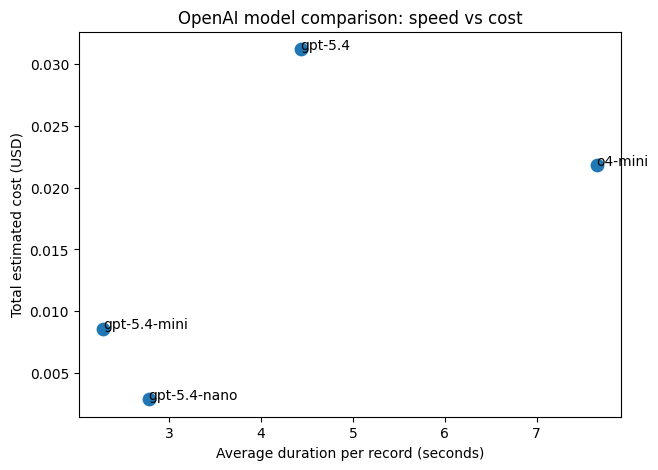

In [23]:
import matplotlib.pyplot as plt

if not summary.empty:
    plot_df = summary.copy()
    ax = plot_df.plot.scatter(x="avg_duration_s", y="total_estimated_cost_usd", s=80, figsize=(7, 5))
    for _, row in plot_df.iterrows():
        ax.annotate(row["model"], (row["avg_duration_s"], row["total_estimated_cost_usd"]))
    ax.set_xlabel("Average duration per record (seconds)")
    ax.set_ylabel("Total estimated cost (USD)")
    ax.set_title("OpenAI model comparison: speed vs cost")
    plt.show()